In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.impute import SimpleImputer
import math as mt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r"C:\Users\omarn\Downloads\Arrhythmia\arrhythmia.csv")
df.head()


,75,0,190,80,91,193,371,174,121,-16,...,0.0.38,9.0,-0.9,0.0.39,0.0.40,0.9.2,2.9.1,23.3,49.4,8
0,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
1,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
2,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
3,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
4,13,0,169,51,100,167,321,174,91,107,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Columns: 280 entries, 75 to 8
dtypes: float64(120), int64(155), object(5)
memory usage: 986.7+ KB


### data cleaning

In [4]:
pd.isnull(df).sum().sum()

0

In [5]:
df=df.replace('?',np.nan)
df.isnull().sum().sum()

407

Text(0, 0.5, 'Total number of null value in each column')

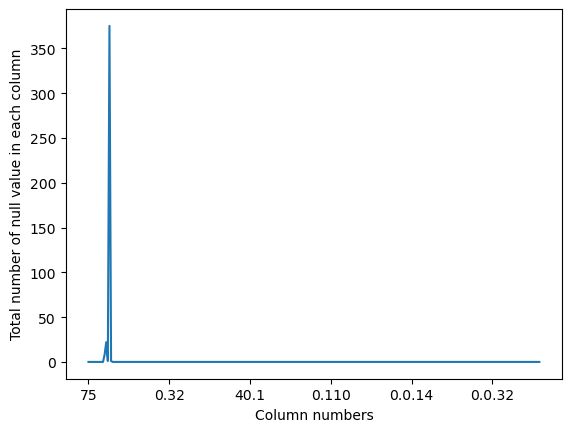

In [6]:
pd.isnull(df).sum().plot()
plt.xlabel('Column numbers')
plt.ylabel('Total number of null value in each column')

Text(0, 0.5, 'Total number of null value in each column')

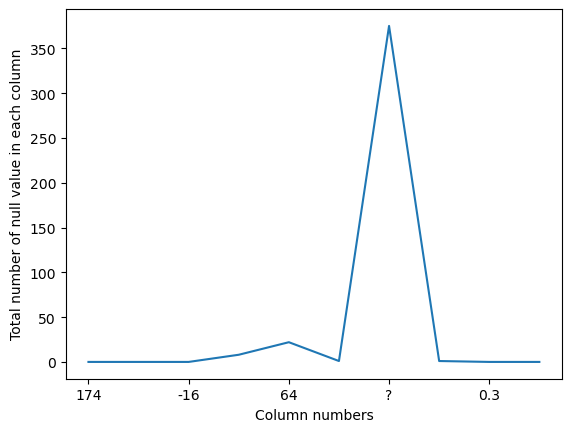

In [7]:
pd.isnull(df).sum()[7:17].plot(kind='line')
plt.xlabel('Column numbers')
plt.ylabel('Total number of null value in each column')

In [8]:
df.columns = range(1, len(df.columns) + 1)

Text(0, 0.5, 'Total number of null value in each column')

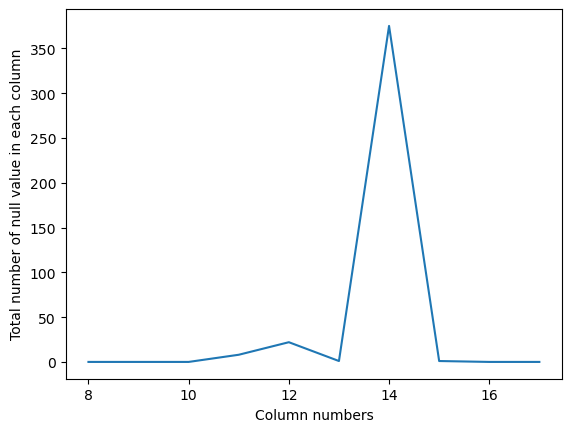

In [9]:
pd.isnull(df).sum()[7:17].plot(kind='line')
plt.xlabel('Column numbers')
plt.ylabel('Total number of null value in each column')

In [10]:
df.drop(columns=12, inplace=True)

In [11]:
df.head()

,1,2,3,4,5,6,7,8,9,10,...,271,272,273,274,275,276,277,278,279,280
0,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
1,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
2,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
3,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
4,13,0,169,51,100,167,321,174,91,107,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14


In [12]:
new_df = df.copy()

In [13]:
col_with_missing = (col for col in new_df.columns if new_df[col].isnull().any())

for col in col_with_missing:
    new_df[col] = new_df[col].isnull()

In [14]:
my_imputer = SimpleImputer()
new_df = pd.DataFrame(my_imputer.fit_transform(new_df))
new_df.columns = new_df.columns

In [15]:
new_df.head()

,0,1,2,3,4,5,6,7,8,9,...,269,270,271,272,273,274,275,276,277,278
0,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6.0
1,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10.0
2,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1.0
3,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7.0
4,13.0,0.0,169.0,51.0,100.0,167.0,321.0,174.0,91.0,107.0,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14.0


In [16]:
pd.isnull(new_df).sum().sum()

0

generate final dataset

In [17]:
#Creating column names

final_df_columns=["Age","Sex","Height","Weight","QRS_Dur",
"P-R_Int","Q-T_Int","T_Int","P_Int","QRS","T","P","J","Heart_Rate",
"Q_Wave","R_Wave","S_Wave","R'_Wave","S'_Wave","Int_Def","Rag_R_Nom",
"Diph_R_Nom","Rag_P_Nom","Diph_P_Nom","Rag_T_Nom","Diph_T_Nom", 
"DII00", "DII01","DII02", "DII03", "DII04","DII05","DII06","DII07","DII08","DII09","DII10","DII11",
"DIII00","DIII01","DIII02", "DIII03", "DIII04","DIII05","DIII06","DIII07","DIII08","DIII09","DIII10","DIII11",
"AVR00","AVR01","AVR02","AVR03","AVR04","AVR05","AVR06","AVR07","AVR08","AVR09","AVR10","AVR11",
"AVL00","AVL01","AVL02","AVL03","AVL04","AVL05","AVL06","AVL07","AVL08","AVL09","AVL10","AVL11",
"AVF00","AVF01","AVF02","AVF03","AVF04","AVF05","AVF06","AVF07","AVF08","AVF09","AVF10","AVF11",
"V100","V101","V102","V103","V104","V105","V106","V107","V108","V109","V110","V111",
"V200","V201","V202","V203","V204","V205","V206","V207","V208","V209","V210","V211",
"V300","V301","V302","V303","V304","V305","V306","V307","V308","V309","V310","V311",
"V400","V401","V402","V403","V404","V405","V406","V407","V408","V409","V410","V411",
"V500","V501","V502","V503","V504","V505","V506","V507","V508","V509","V510","V511",
"V600","V601","V602","V603","V604","V605","V606","V607","V608","V609","V610","V611",
"JJ_Wave","Amp_Q_Wave","Amp_R_Wave","Amp_S_Wave","R_Prime_Wave","S_Prime_Wave","P_Wave","T_Wave",
"QRSA","QRSTA","DII170","DII171","DII172","DII173","DII174","DII175","DII176","DII177","DII178","DII179",
"DIII180","DIII181","DIII182","DIII183","DIII184","DIII185","DIII186","DIII187","DIII188","DIII189",
"AVR190","AVR191","AVR192","AVR193","AVR194","AVR195","AVR196","AVR197","AVR198","AVR199",
"AVL200","AVL201","AVL202","AVL203","AVL204","AVL205","AVL206","AVL207","AVL208","AVL209",
"AVF210","AVF211","AVF212","AVF213","AVF214","AVF215","AVF216","AVF217","AVF218","AVF219",
"V1220","V1221","V1222","V1223","V1224","V1225","V1226","V1227","V1228","V1229",
"V2230","V2231","V2232","V2233","V2234","V2235","V2236","V2237","V2238","V2239",
"V3240","V3241","V3242","V3243","V3244","V3245","V3246","V3247","V3248","V3249",
"V4250","V4251","V4252","V4253","V4254","V4255","V4256","V4257","V4258","V4259",
"V5260","V5261","V5262","V5263","V5264","V5265","V5266","V5267","V5268","V5269",
"V6270","V6271","V6272","V6273","V6274","V6275","V6276","V6277","V6278","V6279","class"]

In [18]:
new_df.columns=final_df_columns
new_df.to_csv('new_arrhythmia.csv', index=False)


In [19]:
new_df.head()

,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279,class
0,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6.0
1,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10.0
2,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1.0
3,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7.0
4,13.0,0.0,169.0,51.0,100.0,167.0,321.0,174.0,91.0,107.0,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14.0


In [20]:
X = new_df.drop('class', axis=1)
y = new_df['class']

In [21]:
X.shape

(451, 278)

In [22]:
#List with class names

class_names = ["Normal", 
               "Ischemic changes (CAD)", 
               "Old Anterior Myocardial Infraction",
               "Old Inferior Myocardial Infraction",
               "Sinus tachycardy", 
               "Sinus bradycardy", 
               "Ventricular Premature Contraction (PVC)",
               "Supraventricular Premature Contraction",
               "Left Boundle branch block",
               "Right boundle branch block",
               "1.Degree AtrioVentricular block",
               "2.Degree AV block",
               "3.Degree AV block",
               "Left Ventricule hypertrophy",
               "Atrial Fibrillation or Flutter",
               "Others"]

In [23]:
t=new_df.sort_values(by='class')

In [24]:
la = t['class'].value_counts(sort=False).to_list()
la

[245, 44, 15, 15, 13, 25, 3, 1, 9, 50, 4, 5, 22]

<Axes: xlabel='class', ylabel='count'>

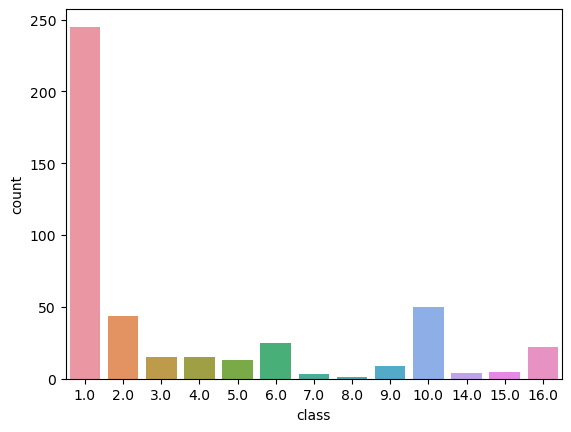

In [25]:
sns.countplot(x='class', data=new_df)


In [26]:
values = la[0:10]
values.extend([0,0,0])
values.extend(la[10:13])
print(values)

[245, 44, 15, 15, 13, 25, 3, 1, 9, 50, 0, 0, 0, 4, 5, 22]


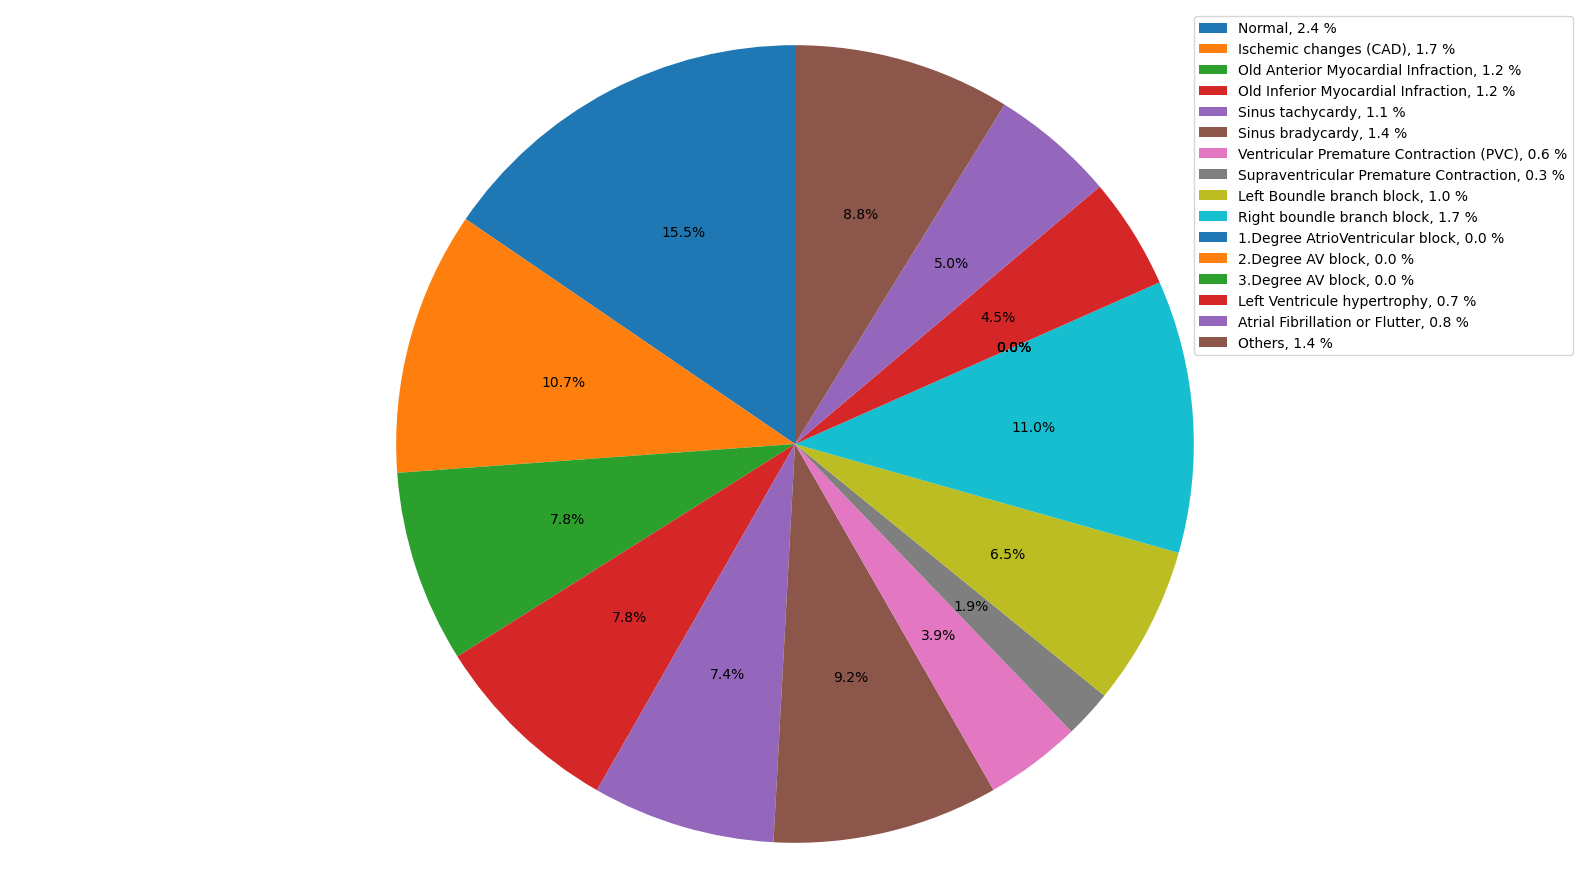

In [27]:
labels = class_names
Log_Norm = []
for i in values:
    Log_Norm.append(mt.log10(i+1))
fig1, ax1 = plt.subplots(figsize=(16,9))
patches = plt.pie(Log_Norm, autopct='%1.1f%%', startangle=90)

leg = plt.legend( loc = 'best', labels=['%s, %1.1f %%' % (l, s) for l, s in zip(labels, Log_Norm)])
plt.axis('equal')

for text in leg.get_texts():
    plt.setp(text, color = 'Black')
plt.tight_layout()
plt.show()

Handling Outliers & Data Visualization

c:\Users\omarn\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


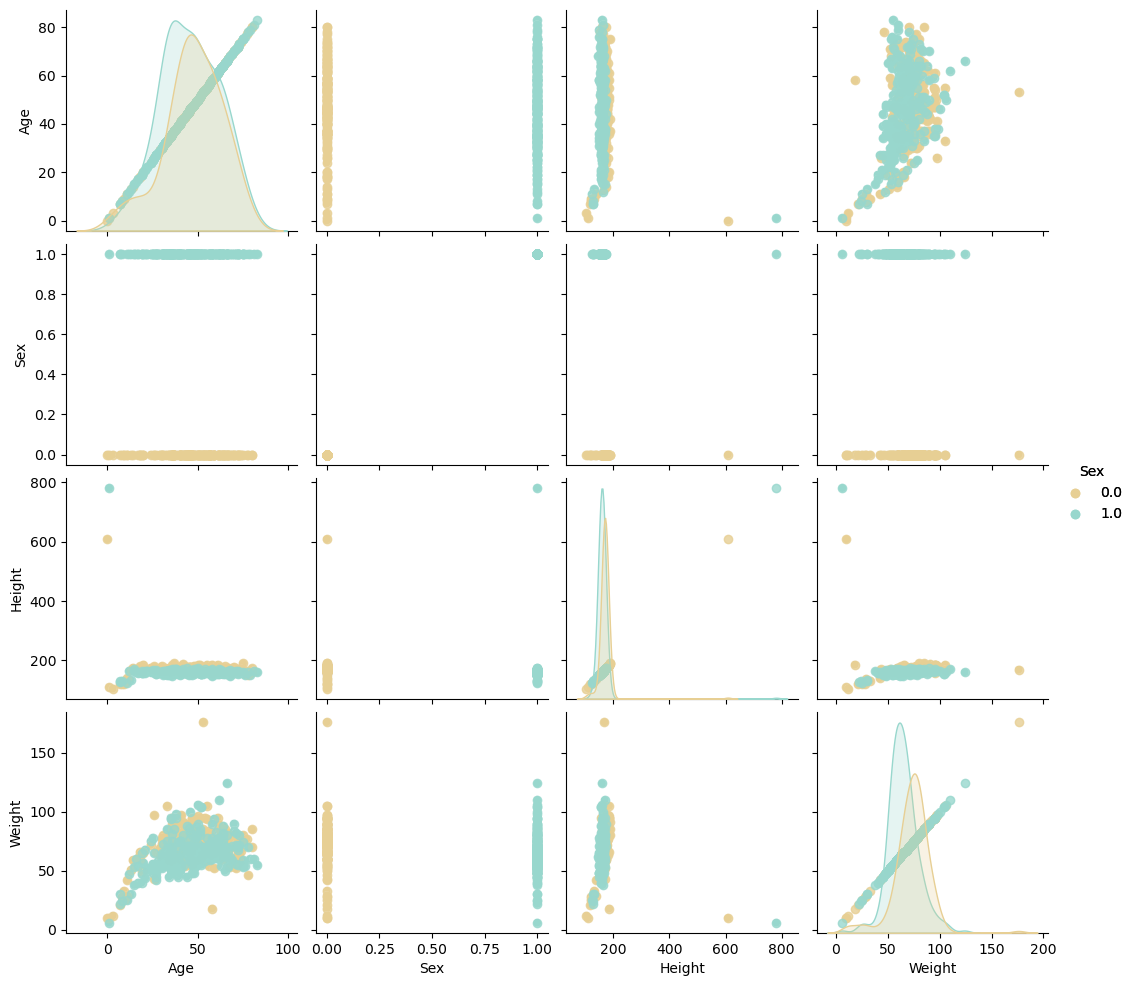

In [28]:
g =sns.pairplot(X, vars=['Age', 'Sex', 'Height', 'Weight'], hue='Sex', palette='BrBG')
g.map(plt.scatter, alpha=0.8)
g.add_legend();

In [29]:
sorted(X['Height'], reverse=True)[0:10]


[780.0, 608.0, 190.0, 190.0, 188.0, 186.0, 186.0, 186.0, 185.0, 185.0]

In [30]:
X['Height'] = X['Height'].replace(780.0, 180.0)
X['Height'] = X['Height'].replace(608.0, 108.0)

In [31]:
sorted(X['Height'], reverse=True)[0:10]

[190.0, 190.0, 188.0, 186.0, 186.0, 186.0, 185.0, 185.0, 185.0, 184.0]

In [32]:
sorted(X['Weight'], reverse=True)[0:10]

[176.0, 124.0, 110.0, 106.0, 105.0, 105.0, 104.0, 104.0, 100.0, 98.0]

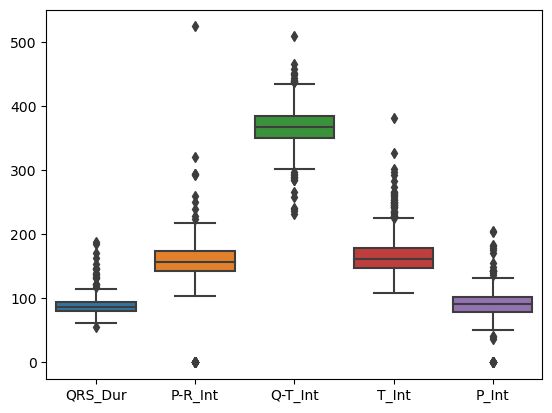

In [33]:

sns.boxplot(data=X[["QRS_Dur","P-R_Int","Q-T_Int","T_Int","P_Int"]]);

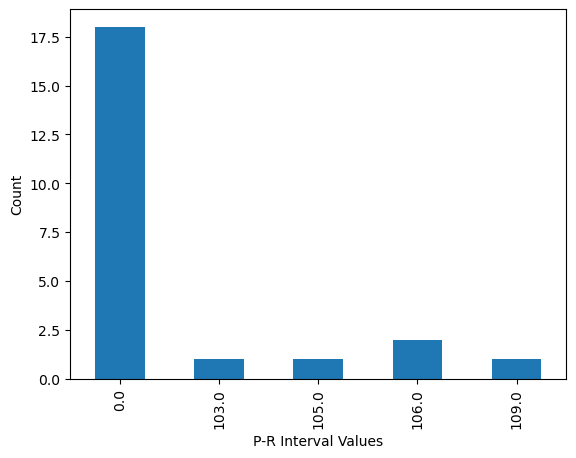

In [34]:
X['P-R_Int'].value_counts().sort_index().head().plot(kind='bar')
plt.xlabel('P-R Interval Values')
plt.ylabel('Count');

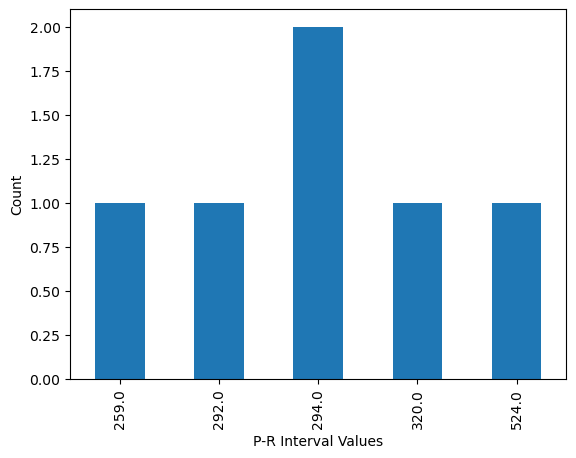

In [35]:
X['P-R_Int'].value_counts().sort_index().tail().plot(kind='bar')
plt.xlabel('P-R Interval Values')
plt.ylabel('Count');

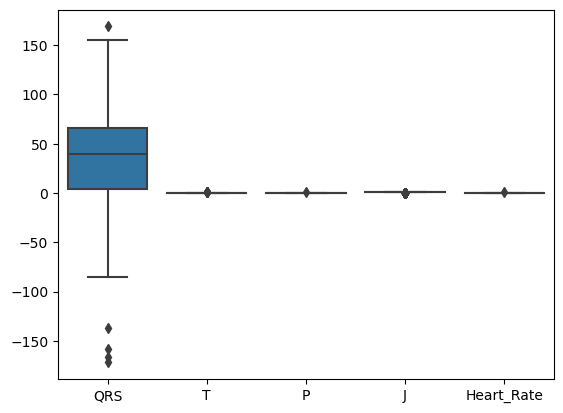

In [36]:
sns.boxplot(data=X[["QRS","T","P","J","Heart_Rate"]]);


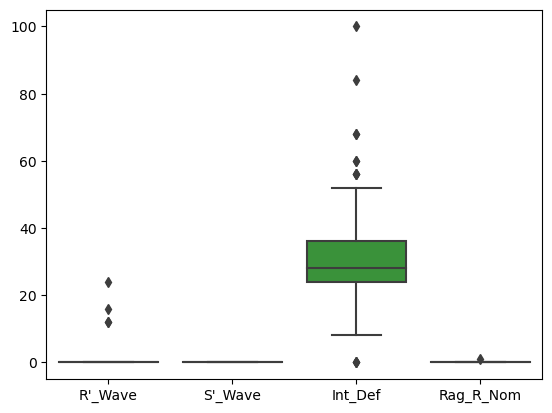

In [37]:
sns.boxplot(data=X[["R'_Wave","S'_Wave","Int_Def","Rag_R_Nom"]]);


In [38]:
X["S'_Wave"].value_counts().sort_index(ascending=False)


S'_Wave
0.0    451
Name: count, dtype: int64

In [39]:
X["V101"].value_counts().sort_index(ascending=False)


V101
216.0     1
112.0     1
84.0      1
72.0      1
68.0      1
64.0      1
48.0      6
44.0      6
40.0     13
36.0     36
32.0     63
28.0     81
24.0     88
20.0     57
16.0     13
12.0      4
0.0      78
Name: count, dtype: int64

In [40]:
X["V201"].value_counts().sort_index(ascending=False)


V201
216.0     1
136.0     1
84.0      1
72.0      1
60.0      5
56.0      4
52.0     12
48.0     19
44.0     53
40.0     67
36.0     74
32.0     69
28.0     48
24.0     39
20.0     15
16.0      6
12.0      2
0.0      34
Name: count, dtype: int64

In [41]:
X["V301"].value_counts().sort_index(ascending=False)


V301
132.0     1
88.0      2
76.0      2
72.0      1
68.0      2
64.0      3
60.0     16
56.0     26
52.0     57
48.0     67
44.0     76
40.0     74
36.0     49
32.0     32
28.0     13
24.0      4
20.0      6
16.0      1
0.0      19
Name: count, dtype: int64

In [42]:
X["V501"].value_counts().sort_index(ascending=False)


V501
136.0      1
120.0      2
116.0      1
108.0      1
96.0       1
92.0       1
84.0       1
76.0       2
72.0       3
68.0       4
64.0       5
60.0       9
56.0      22
52.0      66
48.0     105
44.0     104
40.0      73
36.0      29
32.0      12
28.0       3
24.0       2
20.0       1
0.0        3
Name: count, dtype: int64

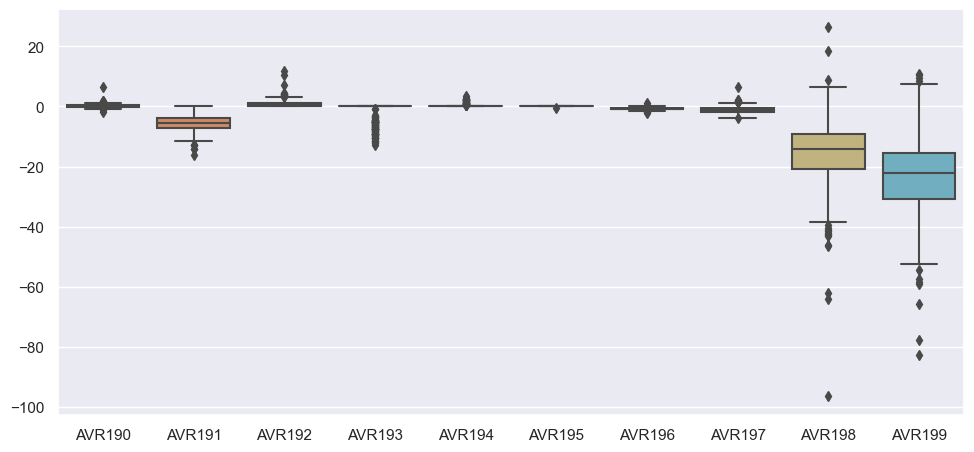

In [43]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=X[["AVR190","AVR191","AVR192","AVR193","AVR194","AVR195","AVR196","AVR197","AVR198","AVR199"]]);

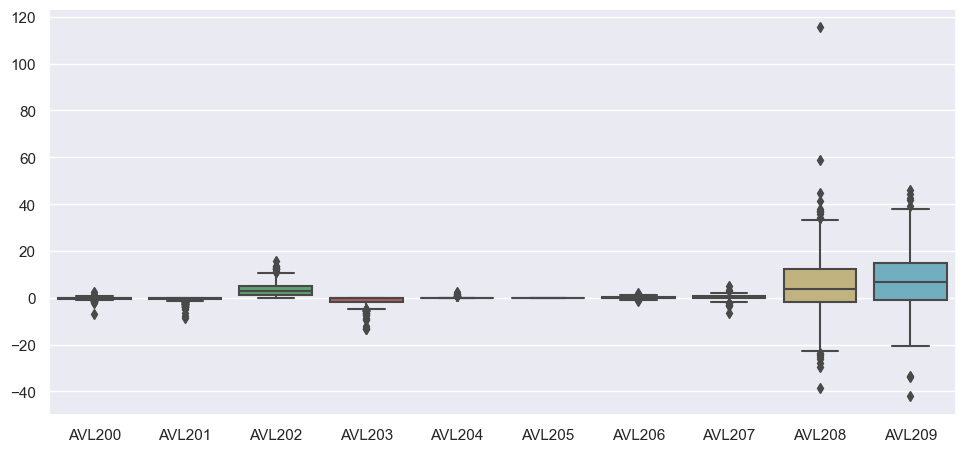

In [44]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=X[["AVL200","AVL201","AVL202","AVL203","AVL204","AVL205","AVL206","AVL207","AVL208","AVL209"]]);

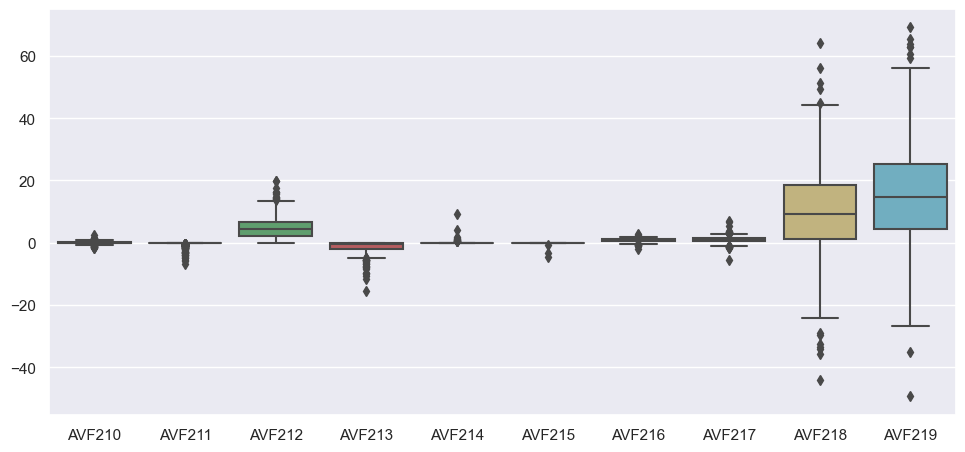

In [45]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=X[["AVF210","AVF211","AVF212","AVF213","AVF214","AVF215","AVF216","AVF217","AVF218","AVF219"]]);

In [46]:
#finding correlation with target feature using pearson correlation

target=new_df["class"]
pearsoncorr = X.corrwith(other = target,method='pearson')
pearsoncorr.values

array([-9.63953176e-02, -1.76192726e-01, -4.00467159e-02, -9.17727611e-02,
        3.23918775e-01, -1.01886734e-01,  2.80967349e-02,  9.74853414e-02,
       -1.24816358e-01,  2.19071159e-02,  1.09973839e-04, -3.07437189e-02,
       -1.24816648e-01,  3.34975965e-02,  5.06916325e-03,  4.26729753e-02,
        1.93323243e-01,  6.42496273e-02,             nan,  4.24003165e-02,
       -2.00368330e-02,  7.90239377e-03, -3.53848077e-02,  3.22668039e-02,
        3.22668039e-02,  8.33337655e-02, -2.57462471e-03,  4.96802756e-02,
        1.83319405e-01, -4.09620130e-02,  6.67239854e-02,  6.86287753e-02,
        4.20776827e-02,  8.02811682e-02, -2.00368330e-02,  1.71081283e-02,
       -3.59472363e-02, -4.06504070e-04, -2.71876432e-02,  1.16808189e-01,
        8.34787880e-02,  1.49651215e-02, -3.18332296e-02,  8.03801729e-02,
       -3.07437189e-02,  5.18840837e-02, -3.07437189e-02, -8.38254438e-02,
       -1.13363624e-02, -5.62988506e-03,  2.05040713e-02,  1.75964215e-01,
        3.43370158e-03,  

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=44, shuffle =True)

In [48]:

#Splitted Data
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (360, 278)
X_test shape is  (91, 278)
y_train shape is  (360,)
y_test shape is  (91,)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
import warnings
warnings.filterwarnings('ignore')

In [51]:
# importing evaluation metrices.

from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,recall_score,precision_score,confusion_matrix,classification_report
from scikitplot.metrics import plot_confusion_matrix,plot_roc


modeling

In [52]:
# will store result of each model.

result = pd.DataFrame(columns=['Model','Train Accuracy','Test Accuracy'])

knn

In [53]:

from sklearn.neighbors import KNeighborsClassifier
knnclassifier = KNeighborsClassifier()
knnclassifier.fit(X_train, y_train)
y_pred = knnclassifier.predict(X_test)

In [54]:
knn_train_accuracy = accuracy_score(y_train, knnclassifier.predict(X_train))
knn_test_accuracy = accuracy_score(y_test, knnclassifier.predict(X_test))
knn_train_recall = recall_score(y_train, knnclassifier.predict(X_train),average="weighted")
knn_test_recall = recall_score(y_test, knnclassifier.predict(X_test),average="weighted")

In [55]:
print('Train Recall score: {}'
      .format(knn_train_recall))
print('Test Recall score: {}'
      .format(knn_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 0.6527777777777778
Test Recall score: 0.5384615384615384


array([[44,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [10,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 8,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [56]:
new_row = pd.DataFrame([{
    'Model': 'KNN Classifier',
    'Train Accuracy': knn_train_accuracy,
    'Test Accuracy': knn_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [57]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462


Logistic regression

In [58]:
from sklearn.linear_model import LogisticRegression
lgclassifier = LogisticRegression(solver = 'saga',random_state = 0) 
lgclassifier.fit(X_train, y_train) 
y_pred = lgclassifier.predict(X_test)

In [ ]:

lg_train_recall = recall_score(y_train, lgclassifier.predict(X_train),average='weighted')
lg_test_recall = recall_score(y_test, lgclassifier.predict(X_test),average='weighted')
lg_train_accuracy = accuracy_score(y_train, lgclassifier.predict(X_train))
lg_test_accuracy = accuracy_score(y_test, lgclassifier.predict(X_test))

In [60]:
print('Train Recall score: {}'
      .format(lg_train_recall))
print('Test Recall score: {}'
      .format(lg_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 0.9388888888888889
Test Recall score: 0.6703296703296703


array([[37,  4,  0,  0,  1,  1,  0,  0,  2,  0,  0,  0],
       [ 3,  6,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  1,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  0,  1,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0],
       [ 1,  3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [61]:
new_row = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Train Accuracy': lg_train_accuracy,
    'Test Accuracy': lg_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [62]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330


Decision tree

In [63]:
from sklearn.tree import DecisionTreeClassifier 
dtclassifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0,max_depth=5)
dtclassifier.fit(X_train, y_train) 
y_pred_test = dtclassifier.predict(X_test)
y_pred_train = dtclassifier.predict(X_train)


In [64]:
dt_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
dt_test_recall = recall_score(y_test, y_pred_test,average="weighted")
dt_train_accuracy = accuracy_score(y_train,y_pred_train )
dt_test_accuracy = accuracy_score(y_test, y_pred_test)

In [65]:
print('Train Recall score: {}'
      .format(dt_train_recall))
print('Test Recall score: {}'
      .format(dt_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 0.8
Test Recall score: 0.5934065934065934


array([[37,  4,  0,  0,  1,  1,  0,  0,  2,  0,  0,  0],
       [ 3,  6,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  1,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  0,  1,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0],
       [ 1,  3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [66]:
new_row = pd.DataFrame([{
    'Model': 'Decision Tree',
    'Train Accuracy': dt_train_accuracy,
    'Test Accuracy': dt_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [67]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407


linear svc

In [68]:

from sklearn.svm import LinearSVC 
lsvclassifier = LinearSVC(C=0.01)
lsvclassifier.fit(X_train, y_train) 
y_pred_test = lsvclassifier.predict(X_test)
y_pred_train = lsvclassifier.predict(X_train)

In [69]:
lsvc_train_accuracy = accuracy_score(y_train, y_pred_train)
lsvc_test_accuracy = accuracy_score(y_test, y_pred_test)
lsvc_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
lsvc_test_recall = recall_score(y_test, y_pred_test,average="weighted")

In [70]:
print('Train Recall score: {}'
      .format(lsvc_train_recall))
print('Test Recall score: {}'
      .format(lsvc_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 0.875
Test Recall score: 0.7032967032967034


array([[37,  4,  0,  0,  1,  1,  0,  0,  2,  0,  0,  0],
       [ 3,  6,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  1,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  0,  1,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0],
       [ 1,  3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [71]:
new_row = pd.DataFrame([{
    'Model': 'linear SVC',
    'Train Accuracy': lsvc_train_accuracy,
    'Test Accuracy': lsvc_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [72]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407
3,linear SVC,0.875000,0.703297


Kernelized SVM

In [73]:
from sklearn import svm
KSVC_clf = svm.SVC(kernel='sigmoid',C=10,gamma=0.001)
KSVC_clf.fit(X_train, y_train)
y_pred_train = KSVC_clf.predict(X_train)
y_pred_test = KSVC_clf.predict(X_test)

In [74]:
ksvc_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
ksvc_test_recall = recall_score(y_test, y_pred_test,average="weighted")

ksvc_train_accuracy = accuracy_score(y_train, y_pred_train)
ksvc_test_accuracy = accuracy_score(y_test, y_pred_test)

In [75]:
print('Train Recall score: {}'
      .format(ksvc_train_recall))
print('Test Recall score: {}'
      .format(ksvc_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 0.8472222222222222
Test Recall score: 0.6923076923076923


array([[37,  4,  0,  0,  1,  1,  0,  0,  2,  0,  0,  0],
       [ 3,  6,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  1,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  0,  1,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0],
       [ 1,  3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [76]:
new_row = pd.DataFrame([{
    'Model': 'Kernelized  SVC',
    'Train Accuracy': ksvc_train_accuracy,
    'Test Accuracy': ksvc_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [77]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407
3,linear SVC,0.875000,0.703297
4,Kernelized SVC,0.847222,0.692308


Random forest

In [78]:
from sklearn.ensemble import RandomForestClassifier
RandomForestClassifierModel = RandomForestClassifier(criterion = 'gini',n_estimators=100,max_depth=20,random_state=33) 
RandomForestClassifierModel.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, random_state=33)

In [79]:
y_pred_train = RandomForestClassifierModel.predict(X_train)
y_pred_test = RandomForestClassifierModel.predict(X_test)


rf_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
rf_test_recall = recall_score(y_test, y_pred_test,average="weighted")

rf_train_accuracy = accuracy_score(y_train, y_pred_train)
rf_test_accuracy = accuracy_score(y_test, y_pred_test)

In [80]:
print('Train Recall score: {}'
      .format(rf_train_recall))
print('Test Recall score: {}'
      .format(rf_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 1.0
Test Recall score: 0.7252747252747253


array([[37,  4,  0,  0,  1,  1,  0,  0,  2,  0,  0,  0],
       [ 3,  6,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  1,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  0,  1,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0],
       [ 1,  3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [81]:
new_row = pd.DataFrame([{
    'Model': 'random Forest',
    'Train Accuracy': rf_train_accuracy,
    'Test Accuracy': rf_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [82]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407
3,linear SVC,0.875000,0.703297
4,Kernelized SVC,0.847222,0.692308
5,random Forest,1.000000,0.725275


PCA

In [85]:
from sklearn.decomposition import PCA
pca = PCA(0.98)
pca.fit(X_train)
pca.n_components_
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [84]:
from sklearn.model_selection import StratifiedKFold
KFold = StratifiedKFold(n_splits=5)
from sklearn.model_selection import GridSearchCV

knn with pca

In [86]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred_train = knn.predict(X_train_pca)
y_pred_test = knn.predict(X_test_pca)

In [87]:
knn_train_accuracy = accuracy_score(y_train, y_pred_train)
knn_test_accuracy = accuracy_score(y_test, y_pred_test)

knn_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
knn_test_recall = recall_score(y_test, y_pred_test,average="weighted")

In [88]:
print('Train Recall score: {}'
      .format(knn_train_recall))
print('Test Recall score: {}'
      .format(knn_test_recall))
confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.6583333333333333
Test Recall score: 0.5164835164835165


array([[43,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [11,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  0],
       [ 8,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [90]:
new_row = pd.DataFrame([{
    'Model': 'knn',
    'Train Accuracy': knn_train_accuracy,
    'Test Accuracy': knn_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [91]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407
3,linear SVC,0.875000,0.703297
4,Kernelized SVC,0.847222,0.692308
5,random Forest,1.000000,0.725275
6,random Forest,0.658333,0.516484
7,knn,0.658333,0.516484


LogisticRegression with pca

In [101]:
from sklearn.linear_model import LogisticRegression
lgp_clf = LogisticRegression(solver='saga',C=0.01)
lgp_clf.fit(X_train_pca, y_train)
y_pred_train = lgp_clf.predict(X_train_pca)
y_pred_test = lgp_clf.predict(X_test_pca)

In [102]:
lgp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
lgp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
lgp_train_accuracy = accuracy_score(y_train, y_pred_train)
lgp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [103]:
print('Train Recall score: {}'
      .format(lgp_train_recall))
print('Test Recall score: {}'
      .format(lgp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.7916666666666666
Test Recall score: 0.6483516483516484


array([[42,  2,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 6,  4,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  1,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  3,  0,  0,  0,  0],
       [ 5,  0,  0,  0,  0,  0,  0,  0,  5,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [104]:
new_row = pd.DataFrame([{
    'Model': 'Logistic Regression PCA',
    'Train Accuracy': lgp_train_accuracy,
    'Test Accuracy': lgp_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [105]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407
3,linear SVC,0.875000,0.703297
4,Kernelized SVC,0.847222,0.692308
5,random Forest,1.000000,0.725275
6,knn,0.658333,0.516484
7,Logistic Regression PCA,0.791667,0.648352


linear svm with pca

In [106]:
from sklearn.svm import LinearSVC
LSVC_clf = LinearSVC(C=0.001)
LSVC_clf.fit(X_train_pca, y_train)
y_pred_train = LSVC_clf.predict(X_train_pca)
y_pred_test = LSVC_clf.predict(X_test_pca)

In [107]:
lsvcp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
lsvcp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
lsvcp_train_accuracy = accuracy_score(y_train, y_pred_train)
lsvcp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [108]:
print('Train Recall score: {}'
      .format(lsvcp_train_recall))
print('Test Recall score: {}'
      .format(lsvcp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.8083333333333333
Test Recall score: 0.6923076923076923


array([[39,  4,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0],
       [ 3,  6,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  4,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  3,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0]], dtype=int64)

In [109]:
new_row = pd.DataFrame([{
    'Model': 'liner SVC PCA',
    'Train Accuracy': lsvcp_train_accuracy,
    'Test Accuracy': lsvcp_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [110]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407
3,linear SVC,0.875000,0.703297
4,Kernelized SVC,0.847222,0.692308
5,random Forest,1.000000,0.725275
6,knn,0.658333,0.516484
7,Logistic Regression PCA,0.791667,0.648352
8,liner SVC PCA,0.808333,0.692308


kernal svm with pca

In [111]:
from sklearn import svm
KSVC_clf = svm.SVC(kernel='sigmoid',C=10,gamma=0.001)

KSVC_clf.fit(X_train_pca, y_train)
y_pred_train = KSVC_clf.predict(X_train_pca)
y_pred_test = KSVC_clf.predict(X_test_pca)


In [112]:
ksvcp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
ksvcp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
ksvcp_train_accuracy = accuracy_score(y_train, y_pred_train,)
ksvcp_test_accuracy = accuracy_score(y_test, y_pred_test)


In [113]:
print('Train Recall score: {}'
      .format(ksvcp_train_recall))
print('Test Recall score: {}'
      .format(ksvcp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.8305555555555556
Test Recall score: 0.6703296703296703


array([[42,  2,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 4,  5,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 1,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  3,  0,  1,  0,  0],
       [ 5,  0,  0,  0,  0,  0,  0,  0,  5,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  1,  0,  0,  0,  0,  0,  0,  1,  0]], dtype=int64)

In [114]:
new_row = pd.DataFrame([{
    'Model': 'kernel SVC PCA',
    'Train Accuracy': ksvcp_train_accuracy,
    'Test Accuracy': ksvcp_test_accuracy
}])

# Concatenate it with your existing result DataFrame
result = pd.concat([result, new_row], ignore_index=True)

In [115]:
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.652778,0.538462
1,Logistic Regression,0.938889,0.670330
2,Decision Tree,0.800000,0.593407
3,linear SVC,0.875000,0.703297
4,Kernelized SVC,0.847222,0.692308
5,random Forest,1.000000,0.725275
6,knn,0.658333,0.516484
7,Logistic Regression PCA,0.791667,0.648352
8,liner SVC PCA,0.808333,0.692308
9,kernel SVC PCA,0.830556,0.670330


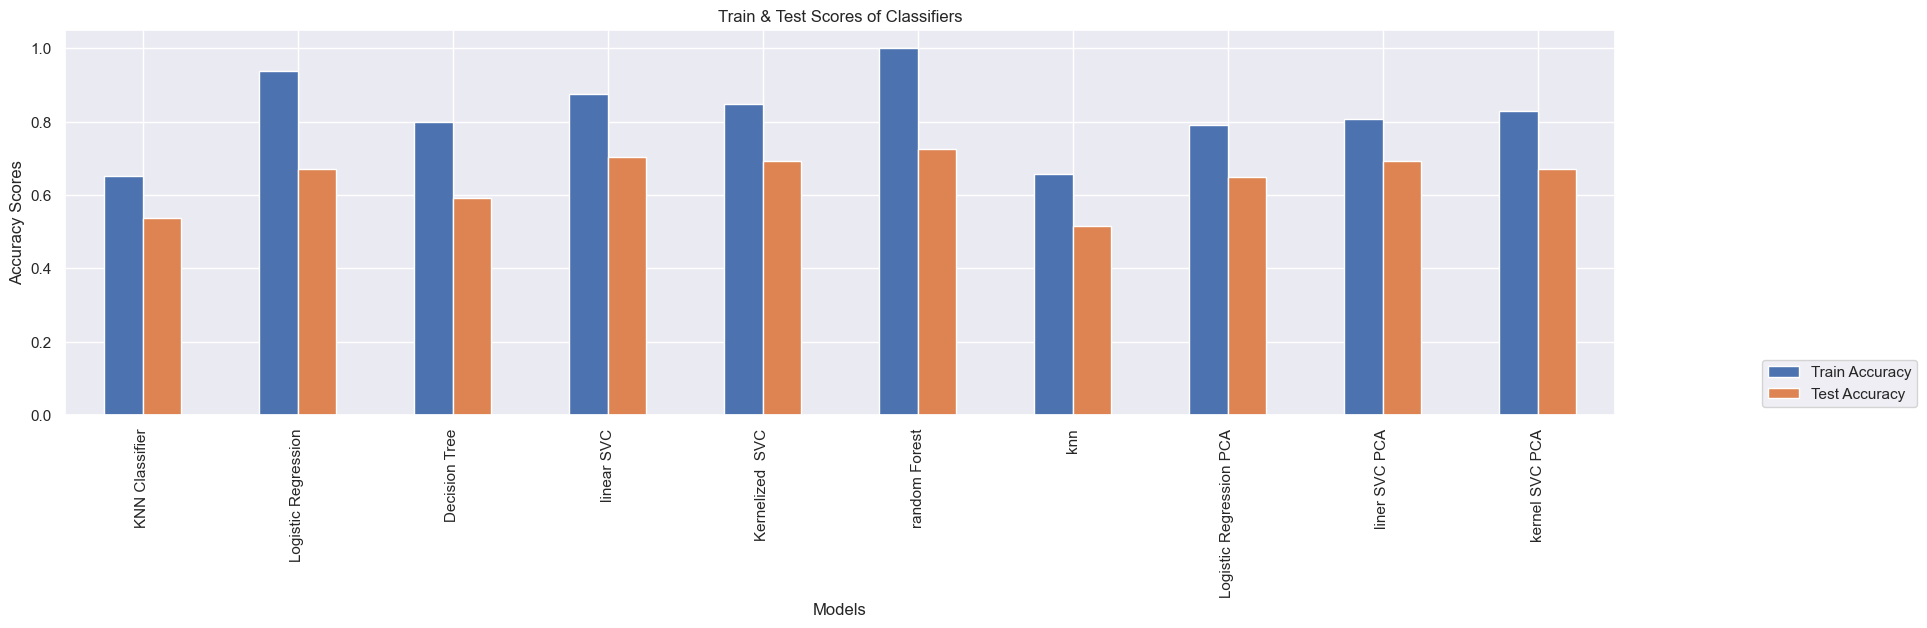

In [116]:
ax=result.plot(kind="bar",figsize=(20,5))
ax.set_xticks(result.index)
ax.set_xticklabels(result.Model,rotation=90)
plt.title('Train & Test Scores of Classifiers')
plt.xlabel('Models')
plt.ylabel('Accuracy Scores')
plt.legend(loc=4 , bbox_to_anchor=(1.2, 0))
plt.show();